In [65]:
import sys
sys.path.append('../')
from NN import neural_network
from head import opentrons
from head import AmplitudePhaseDistance
from scipy.spatial import distance
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import cm

## Import Neural Network and Train Model

In [11]:
exp = neural_network.neural_net()
exp.load_data()
exp.medium_network()
exp.train_model()

0epoch [00:00, ?epoch/s]

Final MSE for train is 1.163e-02 and for validation is 5.143e-02


## Plot Model Predictions with X_test Data

 /mnt/c/Users/htchi/OneDrive/Documents/Retrosynthesis/HEAD/notebooks/../NN/neural_network.py:110: RuntimeWarning:More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


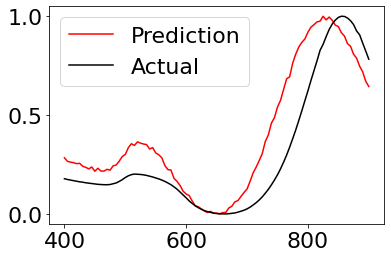

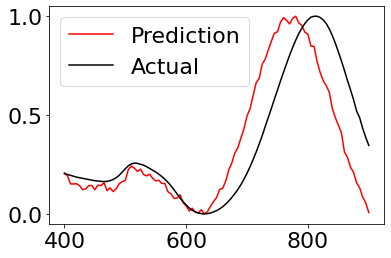

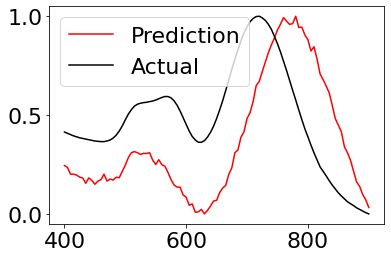

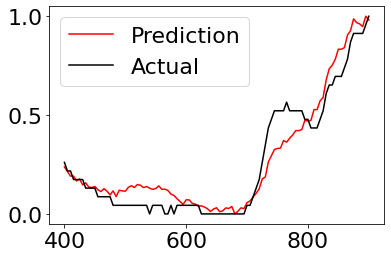

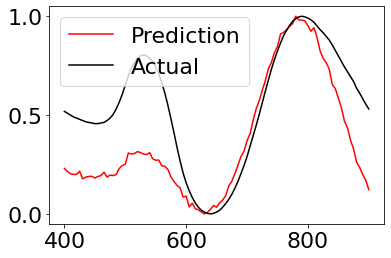

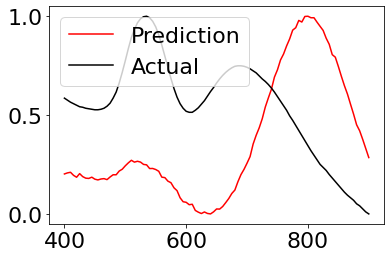

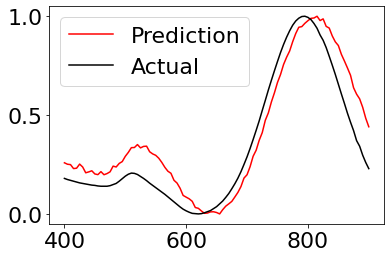

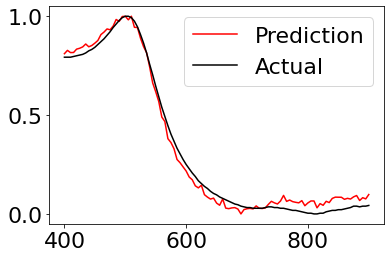

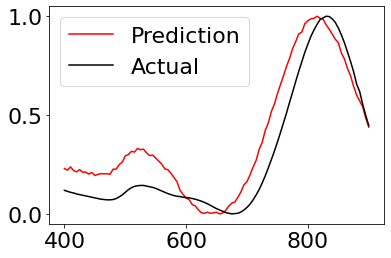

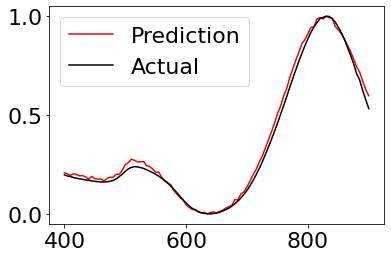

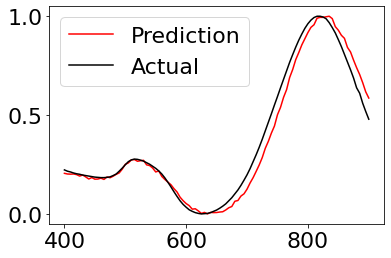

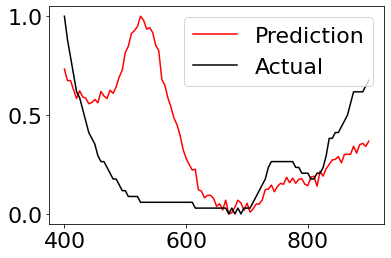

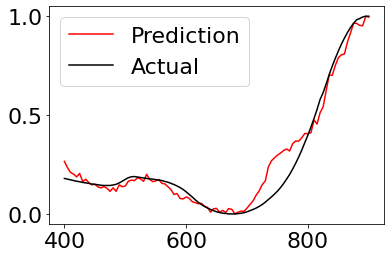

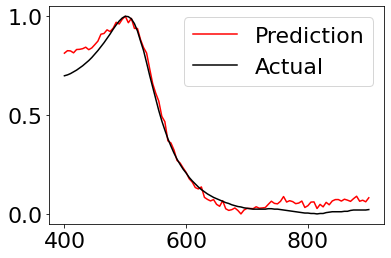

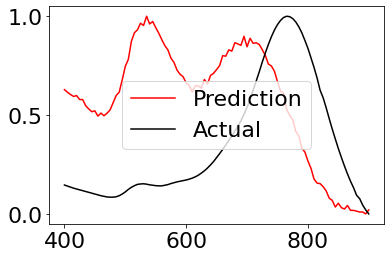

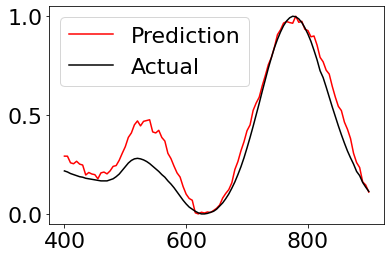

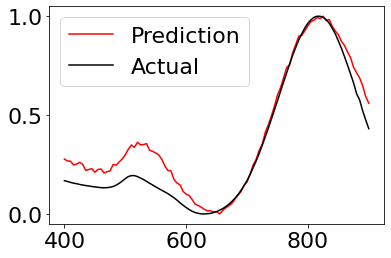

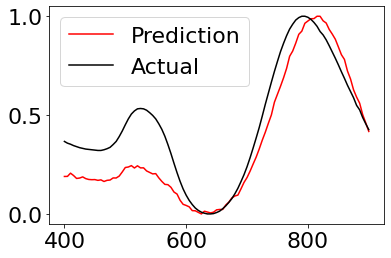

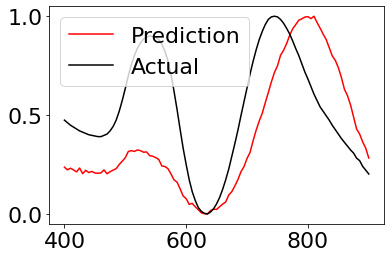

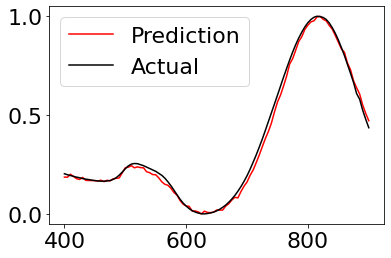

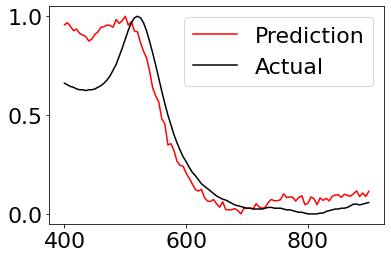

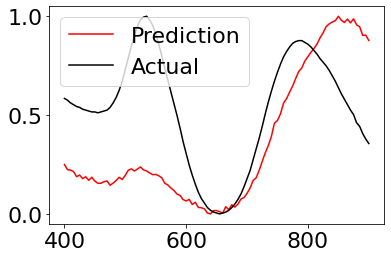

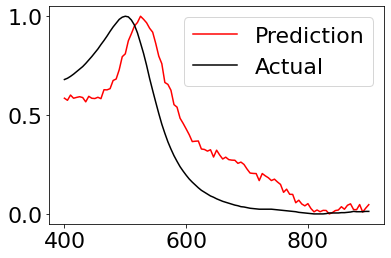

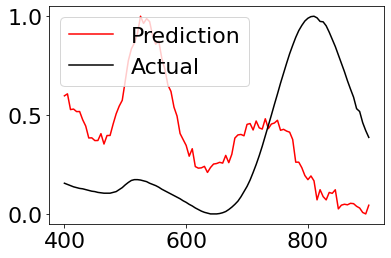

In [12]:
exp.plot_predictions()

## Test Predictions 

In [13]:
x = np.array([[0.5,0.5,0.5,0.5,0.5,1,1,1],[1,1,1,1,1,1,1,1]])
x = np.array([1,1,1,0.5,0.5,0.5,0.5,0.5]).reshape(1,-1)
y_pred, wavelength = exp.predict(x)

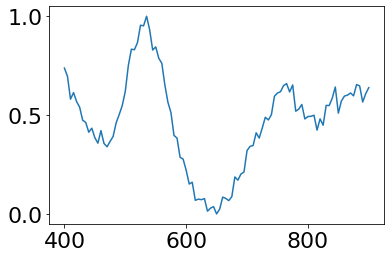

In [14]:
plt.plot(wavelength, y_pred)

## Run Bayesian Optimization

In [140]:
def dist(f1, f2):
    #da, dp = AmplitudePhaseDistance(f1+1e-6, f2+1e-6, xt)
    #d = -(da+dp)
    de = -distance.euclidean(f1, f2)
    d = de
    return d

In [141]:
def simulator(x, fname):
    y_pred, wavelength = exp.predict(x)
    y_pred = np.vstack((wavelength.reshape(1,-1), y_pred))
    df = pd.DataFrame(y_pred.T)
    df.to_excel(fname, index = False)

In [142]:
Range = [0,1]
bounds = [Range, Range, Range, Range, Range, Range, Range, Range]

## Import Target

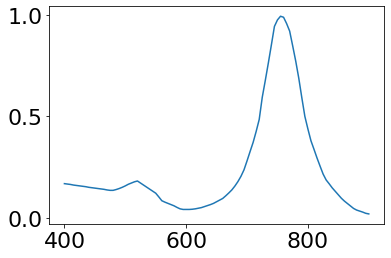

In [143]:
target = pd.read_excel('../Data/Spectra/Target_55nm.xlsx')
target = target.iloc[::5, :]
target = np.asarray(target)
xt = target[:,0]
yt = target[:,1]
plt.plot(xt, yt)

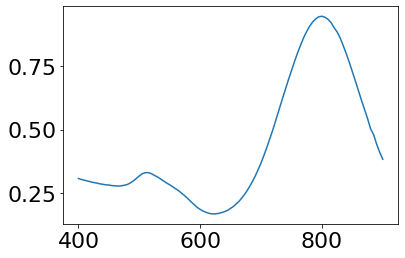

In [144]:
spectra = pd.read_excel('../Data/Spectra/Itr_4.xlsx')
yt = spectra['E1'].values
plt.plot(spectra['Wavelength'], yt)

In [145]:
optim = opentrons.Optimizer(xt, yt, 
                            bounds,
                            savedir = '../BO_simulation',
                            metric = dist,
                            batch_size = 5)

INFO: Getting suggestions for iteration 0
INFO: Iteration : 0, Samples to be made
INFO: 0	[0.47680173 0.73403428 0.30090839 0.70446338 0.6177686  0.94325763
 0.33810103 0.10676983]
INFO: 1	[0.59569972 0.89953114 0.11262688 0.60885072 0.10206531 0.5344496
 0.19571749 0.75575887]
INFO: 2	[0.37813173 0.16415604 0.84129466 0.35125828 0.16332957 0.69752477
 0.01979338 0.4628542 ]
INFO: 3	[0.02216132 0.64735796 0.04526304 0.73481938 0.20742369 0.58100632
 0.92082373 0.43204083]
INFO: 4	[0.66658725 0.80412516 0.22818396 0.63810615 0.65294132 0.31746706
 0.73906405 0.76642928]
INFO: ==============================


In [146]:
optim.save()
C0 = np.load('../BO_simulation/0/new_x.npy')
simulator(C0, '../BO_simulation/0.xlsx')
optim.update('../BO_simulation/0.xlsx')
optim.save()
optim.get_current_best()

 /mnt/c/Users/htchi/OneDrive/Documents/Retrosynthesis/HEAD/notebooks/../head/opentrons.py:228: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
INFO: Iteration : 1 Best estimate [[0.66139801 0.80127579 0.22753577 0.63949489 0.65738662 0.31405368
  0.75208259 0.7657317 ]] with predicted score : [[-1.44341259]]


In [147]:
for i in range(1,10):
    optim.suggest_next()
    optim.save()
    Ci = np.load('../BO_simulation/%d/new_x.npy'%i)
    simulator(Ci, '../BO_simulation/%d.xlsx'%i)
    optim.update('../BO_simulation/%d.xlsx'%i)
    optim.save()
    optim.get_current_best()

INFO: Getting suggestions for iteration 1
 /home/huatthart/miniconda3/envs/neural_net/lib/python3.9/site-packages/gpytorch/utils/cholesky.py:38: NumericalWarning:A not p.d., added jitter of 1.0e-08 to the diagonal
INFO: Iteration : 1, Samples to be made
INFO: 0	[0.92704275 0.7564649  0.19244949 0.56225514 0.81563029 0.1890252
 0.76254473 0.80823044]
INFO: 1	[0.62019889 0.77303597 0.1063124  0.39059592 0.61681559 0.32532598
 0.91548099 0.66251821]
INFO: 2	[0.64683962 0.58476284 0.10812015 0.86526777 0.60994744 0.2445877
 0.80559781 0.69473755]
INFO: 3	[0.32720013 0.75502713 0.18034904 0.71056364 0.48391496 0.41529045
 0.88813361 0.65193136]
INFO: 4	[0.58724319 0.98628618 0.43727085 0.69959356 0.7677558  0.33392239
 0.74613685 0.9099998 ]
INFO: ==============================
 /mnt/c/Users/htchi/OneDrive/Documents/Retrosynthesis/HEAD/notebooks/../head/opentrons.py:228: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone

INFO: ==============================
 /mnt/c/Users/htchi/OneDrive/Documents/Retrosynthesis/HEAD/notebooks/../head/opentrons.py:228: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
INFO: Iteration : 9 Best estimate [[0.27801202 0.76602194 0.20046315 0.69167847 0.39096238 0.48601551
  1.         0.38414135]] with predicted score : [[-0.51285911]]
INFO: Getting suggestions for iteration 9
INFO: Iteration : 9, Samples to be made
INFO: 0	[0.22405869 0.71076093 0.12276522 0.74537513 0.28174242 0.51408935
 1.         0.14920681]
INFO: 1	[0.29494791 0.76448412 0.24117671 0.72949761 0.41801216 0.39212722
 1.         0.4151067 ]
INFO: 2	[0.80431462 0.77859168 0.001      0.60574677 0.74309001 0.40703875
 0.87018595 0.66194345]
INFO: 3	[0.89353819 0.81970954 0.16902489 0.44974868 0.58886183 0.32530815
 0.81326356 0.77881466]
INFO: 4	[0.37893655 0.850956

In [148]:
folder_name = '../BO_simulation/'
iteration = 10
for i in range(1,iteration):
    s_array = np.load(folder_name + str(i) + '/spectra.npy')
    obj = np.load(folder_name + str(i) + '/new_obj.npy')
    if i == 1:
        s_array_all = s_array
        obj_all = obj
    else:
        s_array_all = np.vstack((s_array_all, s_array))
        obj_all = np.vstack((obj_all, obj))
all_spectra = s_array_all

In [149]:
best_score = []
wavelength = np.load(folder_name + '1/wavelengths.npy')
for i in range(1,iteration):
    s_array = np.load(folder_name + str(i) + '/spectra.npy')
    obj = np.load(folder_name + str(i) + '/new_obj.npy')
    x = np.load(folder_name + str(i) + '/new_x.npy')
    array = np.hstack((obj, x, s_array))
    sorted_array = array[np.argsort(array[:, 0])]
    best_x = sorted_array[-1,1:9]
    best_y = sorted_array[-1,9:]
    best_score.append(sorted_array[-1,0])
    if i == 1:
        all_best_x = best_x
        all_best_y = best_y
    else:
        all_best_x = np.vstack((all_best_x, best_x))
        all_best_y = np.vstack((all_best_y, best_y))

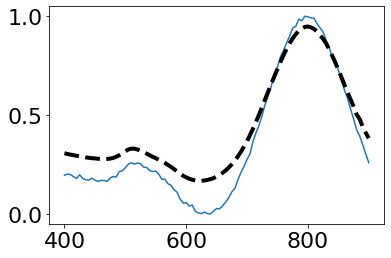

In [150]:
plt.plot(wavelength, best_y)
plt.plot(wavelength, yt, linewidth = 4, color = 'k', label = 'Target', ls='--',)

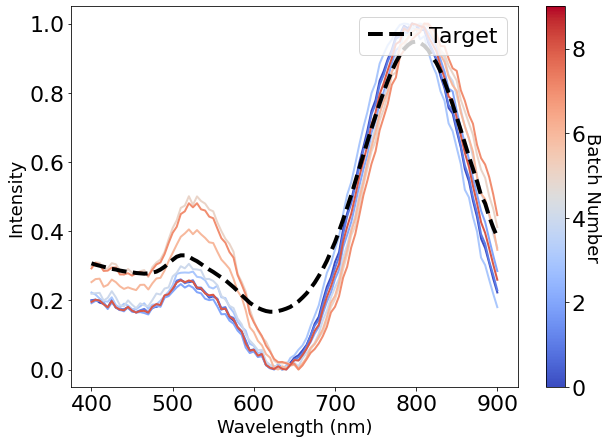

In [151]:
iteration = 9
cmap = cm.get_cmap('coolwarm')
norm = matplotlib.colors.Normalize(vmin=0, vmax = iteration)
fig, ax = plt.subplots(figsize=(10,7))
for i in range(iteration):
    ax.plot(wavelength, all_best_y[i,:], color = cmap(norm(i)), linewidth = 2)
ax.plot(wavelength, yt, linewidth = 4, color = 'k', label = 'Target', ls='--',)
ax.set_xlabel('Wavelength (nm)',fontsize = 18)
ax.set_ylabel('Intensity',fontsize = 18)
ax.legend(loc = 'upper right')
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.ax.set_ylabel('Batch Number', rotation=270, fontsize = 18)
cbar.ax.get_yaxis().labelpad = 15